In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/radia/Downloads/All_scraped_products(in).csv', low_memory=False)

print(df.info()) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482501 entries, 0 to 482500
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   _id              482501 non-null  object 
 1   product_code     482481 non-null  float64
 2   category         378022 non-null  object 
 3   item_name        482193 non-null  object 
 4   best_price       482477 non-null  object 
 5   item_price       454662 non-null  object 
 6   unit_price       462834 non-null  object 
 7   special_text     138658 non-null  object 
 8   promo_text       50171 non-null   object 
 9   link             482482 non-null  object 
 10  extract_date     473137 non-null  object 
 11  best_unit_price  47538 non-null   object 
 12  price_was        14826 non-null   object 
 13  timestamp        290098 non-null  object 
 14  category_slug    201748 non-null  object 
 15  store            482501 non-null  object 
 16  image            110007 non-null  obje

In [2]:
#Clean numeric price columns 

def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace("$", "").replace(",", "").strip()
    return pd.to_numeric(x, errors="coerce")

df["item_price_clean"] = df["item_price"].apply(clean_price)

df["extract_date"] = pd.to_datetime(df["extract_date"], errors="coerce")

#Remove rows without price or date

df = df.dropna(subset=["product_code", "extract_date"])

#Sort the data for timeseries analysis

df = df.sort_values(["product_code", "extract_date"]).copy()

**Outlier Detection**

In [3]:
#Analyze a single product's history to find anomalies relative to itself

def detect_outliers_product_wise(group):
    
    prices = group["item_price_clean"]
    product_median = prices.median()
    
    #Consider only the products with sufficient data
    
    if len(prices) < 3 or pd.isna(product_median) or product_median == 0:
        group["is_spike"] = False
        group["is_extreme_high"] = False
        group["is_deep_discount"] = False
        group["product_median"] = product_median
        return group
    
    #Spike detection
    
    prices = pd.to_numeric(group["item_price_clean"], errors="coerce")
    pct_change = prices.pct_change(fill_method=None)
    price_diff = prices.diff().abs()
    
    #A spike must have a large percentage jump/drop and a dollar change of atleast $1.5
    group["is_spike"] = (pct_change.abs() > 0.60) & (price_diff > 1.50)

    #Extreme High: data entry errors
    group["is_extreme_high"] = prices > (product_median * 3)

    #Deep Discount: Price is less than 60% of the median
    group["is_deep_discount"] = (prices < (product_median * 0.6)) & (prices > 0.10)

    return group

df = df.groupby("product_code", group_keys=False).apply(detect_outliers_product_wise)



In [4]:
#Price Classification

def classify_price(row):
    price = row["item_price_clean"]
    median = row["product_median"]
    
    #System errors: Scraper failures and Impossible prices
    if pd.isna(price) or price <= 0.01:
        return "Zero or Missing Price"
    if price > 3000:
        return "Impossible Price (>$3000)"

    #Data entry errors: statistically high relative to itself
    if row["is_extreme_high"]:
        return "Extreme High (Unit Mismatch)"

    #Sudden abnormal change
    if row["is_spike"]:
        return "High Volatility Spike"

    #Confirmed discount 
    if row["is_deep_discount"]:
        if price < median * 0.05:
            return "Suspiciously Low Price"
        return "Deep Discount"

    return "Normal"

df["price_status"] = df.apply(classify_price, axis=1)
df["is_an_outlier"] = df["price_status"] != "Normal"

<function matplotlib.pyplot.show(close=None, block=None)>

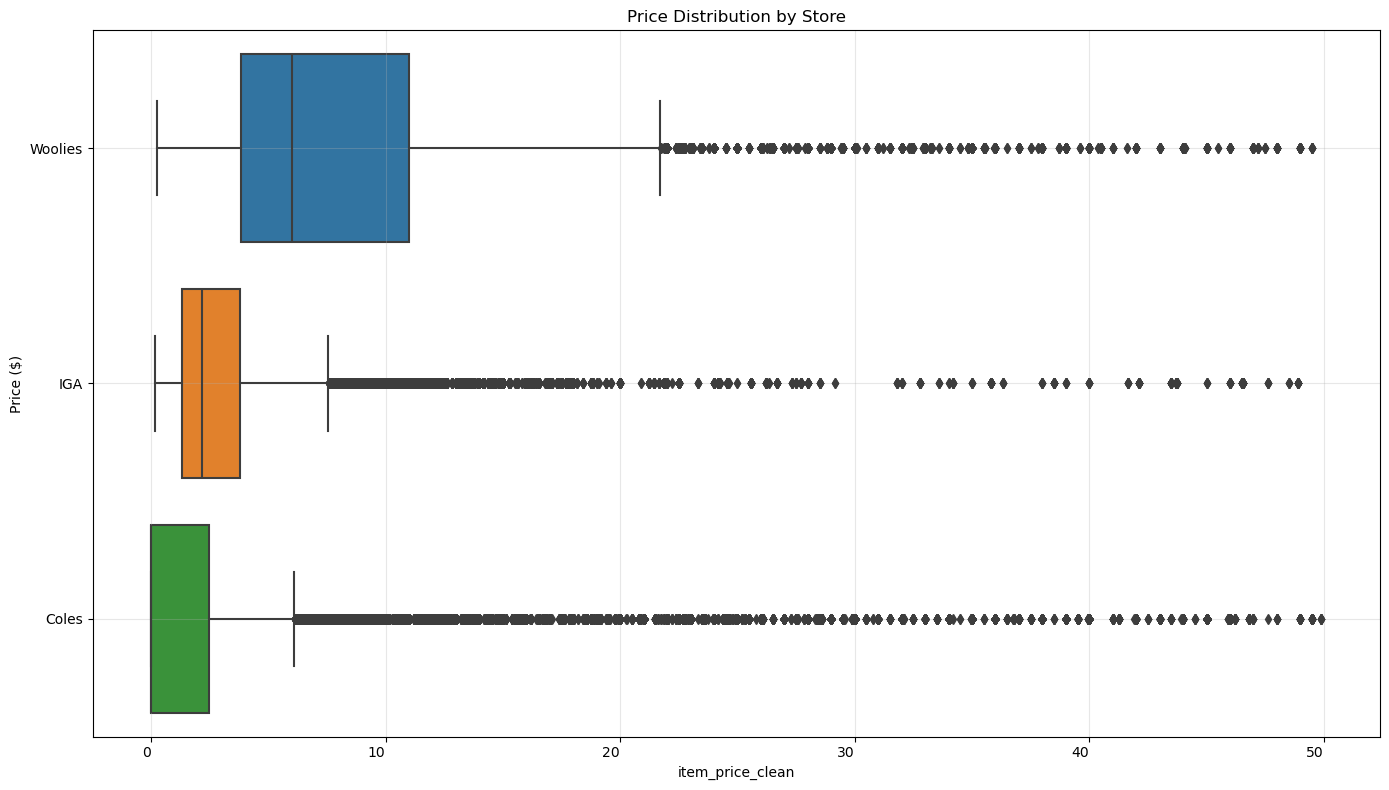

In [5]:
#Box plot as per product

import seaborn as sns

plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df[df["item_price_clean"] < df["item_price_clean"].quantile(0.99)],
    y="store",
    x="item_price_clean",
    orient="h",
    showfliers=True
)
plt.title("Price Distribution by Store")
plt.ylabel("Price ($)")
plt.xticks(rotation=0, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show

In [6]:
print("-" * 40)
print(f"Total Rows: {len(df)}")
print(f"Outliers Detected: {df['is_an_outlier'].sum()}")
print("-" * 40)

print("\nPrice Status Distribution:")
print(df["price_status"].value_counts())

----------------------------------------
Total Rows: 473117
Outliers Detected: 281544
----------------------------------------

Price Status Distribution:
price_status
Zero or Missing Price           261576
Normal                          191573
High Volatility Spike            12569
Deep Discount                     5709
Extreme High (Unit Mismatch)      1690
Name: count, dtype: int64


In [7]:
outlier_report = df[df["is_an_outlier"]][
    ["product_code", "item_name", "category", "store",
     "extract_date", "item_price_clean", "product_median", "price_status"]
]

print(outlier_report.head())
outlier_report.to_csv("/Users/radia/Downloads/outlier_analysis_report.csv", index=False)

        product_code                                   item_name category  \
448759          76.0  Up & Go Liquid Breakfast Strawberry 3 Pack      NaN   
454376          76.0  Up & Go Liquid Breakfast Strawberry 3 Pack      NaN   
459889          76.0  Up & Go Liquid Breakfast Strawberry 3 Pack      NaN   
470179          76.0  Up & Go Liquid Breakfast Strawberry 3 Pack      NaN   
476734          76.0  Up & Go Liquid Breakfast Strawberry 3 Pack      NaN   

       store extract_date  item_price_clean  product_median  \
448759   IGA   2025-09-04               NaN             NaN   
454376   IGA   2025-09-07               NaN             NaN   
459889   IGA   2025-09-10               NaN             NaN   
470179   IGA   2025-09-14               NaN             NaN   
476734   IGA   2025-09-17               NaN             NaN   

                 price_status  
448759  Zero or Missing Price  
454376  Zero or Missing Price  
459889  Zero or Missing Price  
470179  Zero or Missing Price 